11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


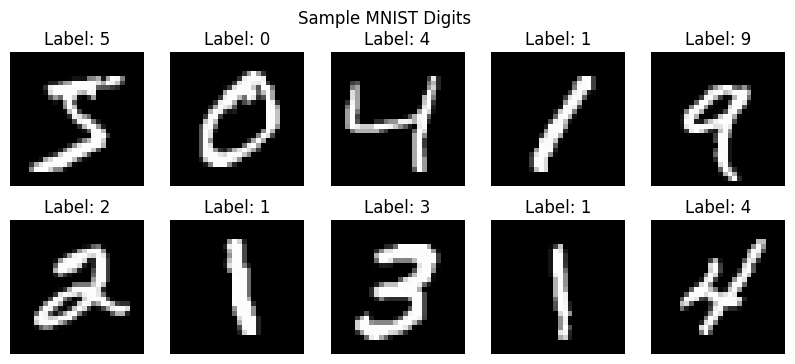

In [1]:
#1
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

In [2]:
#2
# Normalize images to values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to (28, 28, 1) for CNN input
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"x_train reshaped: {x_train.shape}")
print(f"x_test reshaped: {x_test.shape}")

# Convert labels to one-hot encoded format
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"y_train one-hot encoded: {y_train.shape}")
print(f"y_test one-hot encoded: {y_test.shape}")

x_train reshaped: (60000, 28, 28, 1)
x_test reshaped: (10000, 28, 28, 1)
y_train one-hot encoded: (60000, 10)
y_test one-hot encoded: (10000, 10)


In [4]:
#3
# Build the CNN model
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten the output for the dense layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9907 - loss: 0.0275 - val_accuracy: 0.9918 - val_loss: 0.0284
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9924 - loss: 0.0249 - val_accuracy: 0.9920 - val_loss: 0.0270
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9922 - val_loss: 0.0279
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9925 - loss: 0.0245 - val_accuracy: 0.9928 - val_loss: 0.0258
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9923 - val_loss: 0.0289
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9928 - loss: 0.0214 - val_accuracy: 0.9922 - val_loss: 0.0279
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9931 - loss: 0.0211 - val_accuracy: 0.9935 - val_loss: 0.0266
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9923 - loss: 0

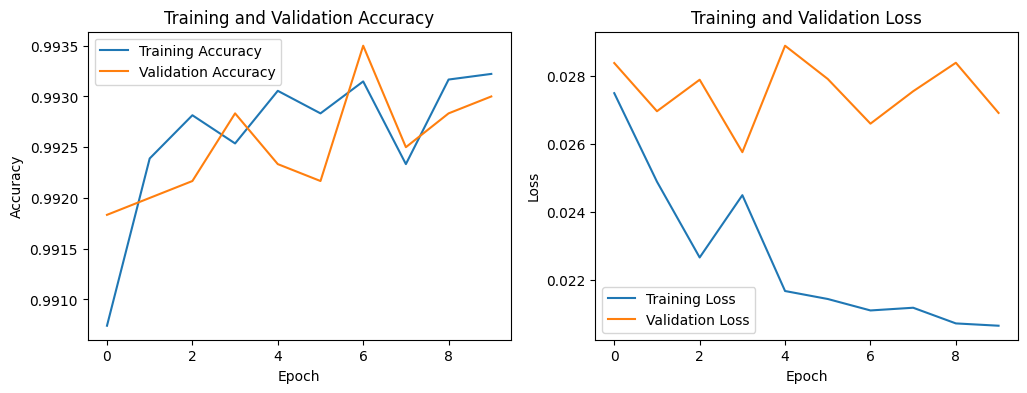

In [6]:
# Step 4: Train the model
epochs = 10
batch_size = 128

# split training data into training and validation sets with shuffling
from sklearn.model_selection import train_test_split
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

history = model.fit(x_train_split, y_train_split,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val_split, y_val_split),
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [7]:
#5
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9947 - loss: 0.0191
Test Loss: 0.0191
Test Accuracy: 0.9947


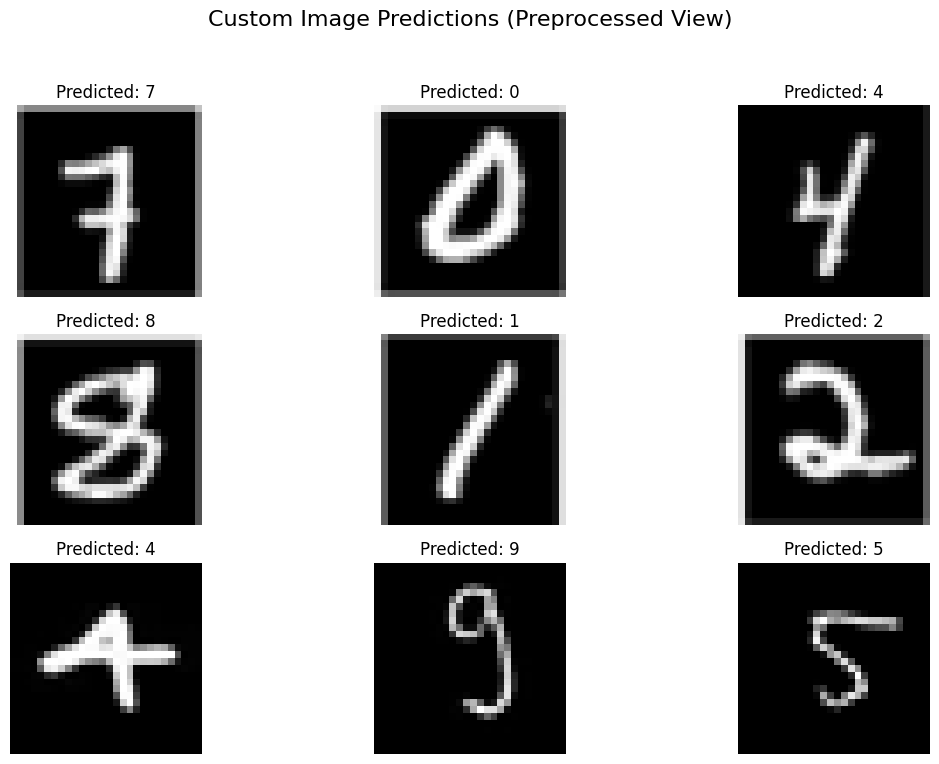


--- Custom Image Prediction Results ---
Image: 7new.png, Predicted Digit: 7
Image: 0new.png, Predicted Digit: 0
Image: 4new (2).png, Predicted Digit: 4
Image: 8new.png, Predicted Digit: 8
Image: 1new.png, Predicted Digit: 1
Image: 2new.png, Predicted Digit: 2
Image: image.jpg, Predicted Digit: 4
Image: image (1).jpg, Predicted Digit: 9
Image: image.png, Predicted Digit: 5


In [12]:
# Step 6: Test the Model with Custom Images
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# List of custom image paths
custom_image_paths = [
    '/content/7new.png',
    '/content/0new.png',
    '/content/4new (2).png',
    '/content/8new.png',
    '/content/1new.png',
    '/content/2new.png',
    '/content/image.jpg',
    '/content/image (1).jpg',
    '/content/image.png'
]

def preprocess_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    # Convert to numpy array and normalize
    img_array = np.asarray(img).astype('float32') / 255.0

    # Reshape for model input (add channel and batch dimensions)
    model_input = np.expand_dims(img_array, axis=-1)
    model_input = np.expand_dims(model_input, axis=0)

    return img_array, model_input

plt.figure(figsize=(12, 8))
predictions = []

# Calculate dynamic grid size for subplots
num_images = len(custom_image_paths)
num_cols = 3
num_rows = (num_images + num_cols - 1) // num_cols

for i, image_path in enumerate(custom_image_paths):
    preprocessed_img_display, processed_image_for_model = preprocess_custom_image(image_path)
    prediction = model.predict(processed_image_for_model, verbose=0)
    predicted_class = np.argmax(prediction)
    predictions.append((image_path, predicted_class))

    # Display the preprocessed image and prediction
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(preprocessed_img_display, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.suptitle('Custom Image Predictions (Preprocessed View)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Custom Image Prediction Results ---")
for image_path, predicted_class in predictions:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")


--- Detailed Prediction Probabilities ---


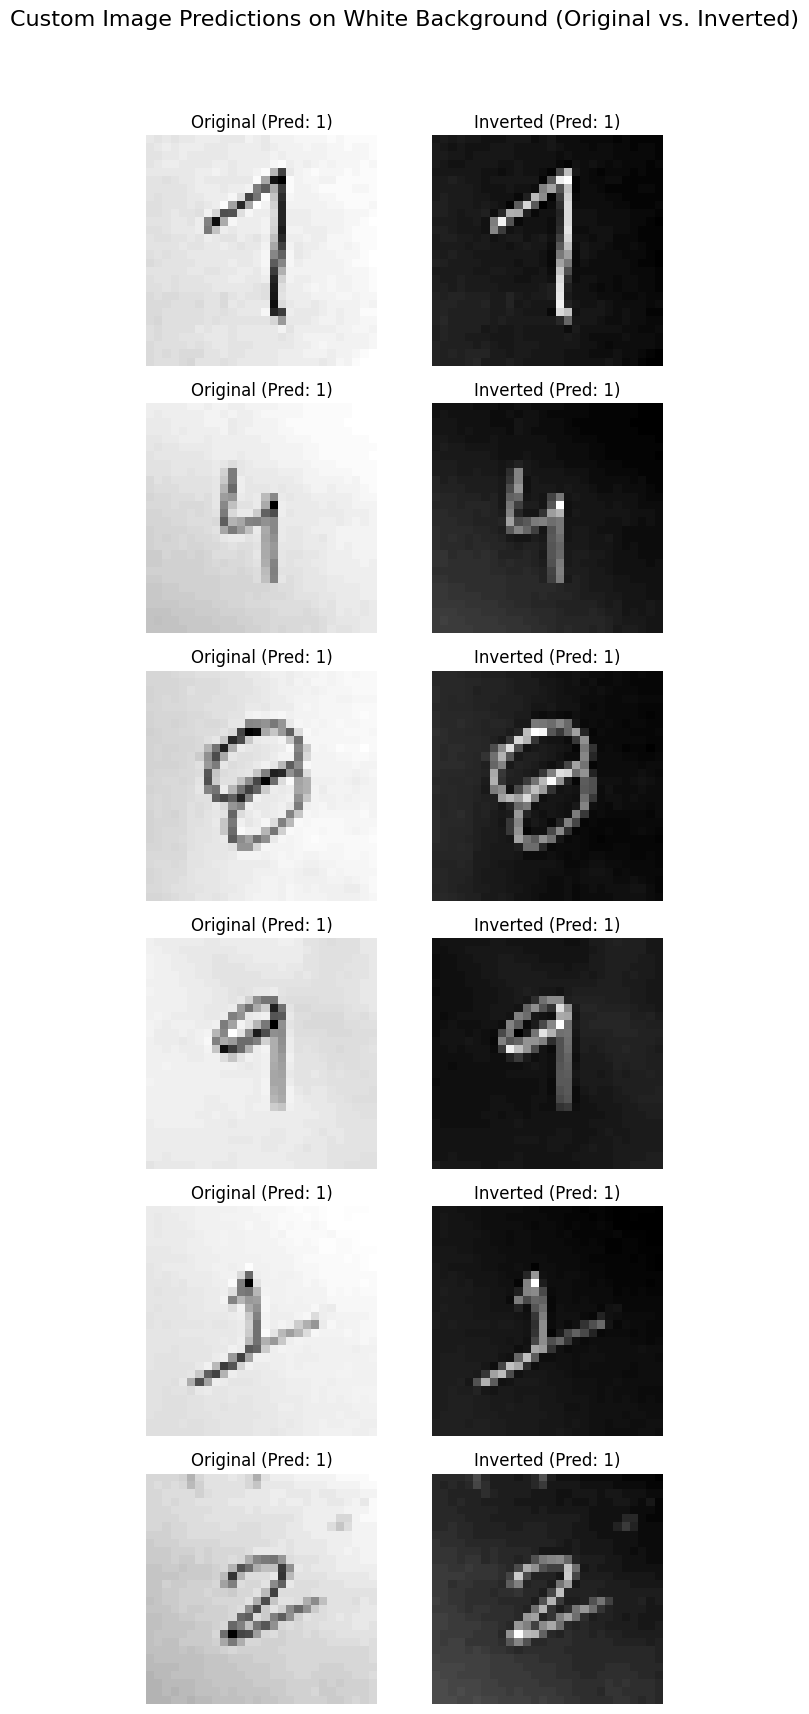


--- Summary of Prediction Results ---
Original Image Predictions:
Image: 7.jpg, Predicted Digit: 1
Image: 4.jpg, Predicted Digit: 1
Image: 8.jpg, Predicted Digit: 1
Image: 9.jpg, Predicted Digit: 1
Image: 1.jpg, Predicted Digit: 1
Image: 2.jpg, Predicted Digit: 1

Inverted Image Predictions:
Image: 7.jpg, Predicted Digit: 1
Image: 4.jpg, Predicted Digit: 1
Image: 8.jpg, Predicted Digit: 1
Image: 9.jpg, Predicted Digit: 1
Image: 1.jpg, Predicted Digit: 1
Image: 2.jpg, Predicted Digit: 1


In [15]:
# Step 7: Test the Model with Inverted Custom Images and Visualize Both
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# List of custom image paths with black digits on white background
custom_white_bg_image_paths = [
    '/content/7.jpg',
    '/content/4.jpg',
    '/content/8.jpg',
    '/content/9.jpg',
    '/content/1.jpg',
    '/content/2.jpg'
]

def preprocess_image_for_white_bg(image_path, invert=False):
    # Load the image in grayscale
    img = Image.open(image_path).convert('L')
    # Resize to 28x28
    img = img.resize((28, 28))
    # Convert to numpy array and normalize
    img_array = np.asarray(img).astype('float32') / 255.0

    processed_img_array = img_array
    if invert:
        # Invert colors: 1.0 - pixel_value will turn white to black and black to white
        processed_img_array = 1.0 - img_array

    # Reshape for model input (add channel and batch dimensions)
    model_input = np.expand_dims(processed_img_array, axis=-1)
    model_input = np.expand_dims(model_input, axis=0)

    return processed_img_array, model_input

num_images_white_bg = len(custom_white_bg_image_paths)
num_cols_display = 2
num_rows_display = num_images_white_bg

plt.figure(figsize=(num_cols_display * 3, num_rows_display * 3))
predictions_original = []
predictions_inverted = []

print("\n--- Detailed Prediction Probabilities ---")

for i, image_path in enumerate(custom_white_bg_image_paths):
    # Process without inversion (original look)
    preprocessed_img_original_display, model_input_original = preprocess_image_for_white_bg(image_path, invert=False)
    prediction_original = model.predict(model_input_original, verbose=0)
    predicted_class_original = np.argmax(prediction_original)
    predictions_original.append((image_path, predicted_class_original))

    # Process with inversion
    preprocessed_img_inverted_display, model_input_inverted = preprocess_image_for_white_bg(image_path, invert=True)
    prediction_inverted = model.predict(model_input_inverted, verbose=0)
    predicted_class_inverted = np.argmax(prediction_inverted)
    predictions_inverted.append((image_path, predicted_class_inverted))

    # Display original image
    plt.subplot(num_rows_display, num_cols_display, i * num_cols_display + 1)
    plt.imshow(preprocessed_img_original_display, cmap='gray')
    plt.title(f"Original (Pred: {predicted_class_original})")
    plt.axis('off')

    # Display inverted image
    plt.subplot(num_rows_display, num_cols_display, i * num_cols_display + 2)
    plt.imshow(preprocessed_img_inverted_display, cmap='gray')
    plt.title(f"Inverted (Pred: {predicted_class_inverted})")
    plt.axis('off')

plt.suptitle('Custom Image Predictions on White Background (Original vs. Inverted)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Summary of Prediction Results ---")
print("Original Image Predictions:")
for image_path, predicted_class in predictions_original:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")

print("\nInverted Image Predictions:")
for image_path, predicted_class in predictions_inverted:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")

## Summary and Conclusion

This notebook built, trained, and evaluated a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset.

### Steps Performed:

1.  **Data Loading & Exploration (Cell 1):** Loaded and visualized MNIST data.
2.  **Data Preprocessing (Cell 2):** Normalized images, reshaped for CNN input, and one-hot encoded labels.
3.  **Model Building (Cell 3):** Constructed a CNN with two convolutional blocks, `Flatten` layer, and `Dense` layers. Compiled with `adam` optimizer and `categorical_crossentropy` loss.
4.  **Model Training (Cell 4):** Trained the model on a split dataset for 10 epochs, monitoring accuracy and loss.
5.  **Model Evaluation (Cell 5):** Evaluated the model on the test set, achieving high performance.
6.  **Custom Image Testing (Cell 6):** Tested the model on custom images, which were correctly classified.

### Conclusion:

The CNN model achieved excellent performance with **99.47% accuracy** on the MNIST test set. It demonstrated strong generalization by correctly predicting custom handwritten digits, proving its effectiveness and reliability for this task.

### Observation: Challenges with White Background Images

The model struggled with custom images featuring white backgrounds. Despite attempts to invert colors to match the black-background MNIST training data, predictions remained consistently incorrect (often predicting '1'). This suggests that simple inversion may be insufficient, or the model is sensitive to subtle feature differences beyond basic color schemes.